In [42]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import chi2
from scipy.stats import gamma
sns.set(font_scale=2)

## 1. Neyman construction

**Core idea of the Neyman construction:**

1. We need to be able to evaluate (or approximate) the sampling distribution of an estimator under the true parameter value:
    $$ p(\hat{\theta}\mid \theta) $$

    ### Q1: Which distribution must we be able to compute for the Neyman construction?

    1) $p(\theta \mid \hat{\theta})$
    2) $p(\hat{\theta}\mid \theta) \; \checkmark$
    3) $p(x\mid \theta)$
    4) $p(\theta \mid x)$
    5) $p(\hat{\theta}\mid x)$

2. Fix the significance level $\alpha$ and an **ordering rule**.

    ### Q2: What is an ordering rule?

    1) A rule for choosing (prioritizing) $\theta$ when building the interval.
    2) A function depending on the likelihood used to define an order.  ✅ (general idea)
    3) A scalar function $f(\hat{\theta})$ defining an order on $\hat{\theta}$, e.g. $f(\hat{\theta}') > f(\hat{\theta}'')$.
    4) There is no correct answer.

3. Perform the measurement and obtain $\hat{\theta}$.

4. (Assume we build a two-sided interval.) solve the following:
    $$
   \mathrm{CDF}_{\hat{\theta}\mid\theta_{\text{low}}}(\hat{\theta}_{\text{obs}})
   = 1 - \alpha/2
   $$

   $$
   \mathrm{CDF}_{\hat{\theta}\mid\theta_{\text{high}}}(\hat{\theta}_{\text{obs}})
   = \alpha/2
   $$

5. Find
  $
  [\theta_{\text{low}},\theta_{\text{high}}]
  $
  which is our confidence interval.


The Neyman construction can be carried out in different ways, depending on how simple or complicated the underlying distribution is.

## 1.1 Normal distribution

### 1. Analytical approach

$$
p(x \mid \mu) = \frac{1}{\sqrt{2\pi}\,\sigma}
\exp\!\left( -\frac{(x - \mu)^2}{2\sigma^2} \right)
= \mathcal{N}(x \mid \mu, \sigma^2)
$$

$$
\hat{\mu} = \frac{1}{n} \sum_i x_i
\;\sim\;
\mathcal{N}\!\left( \mu,\; \frac{\sigma^2}{n} \right)
$$

$$
\mathrm{CDF}_{\hat{\mu}\mid\mu}(\hat{\mu})
=
\frac{1}{2}
\left[
1 + \mathrm{erf}\!\left(
\frac{\hat{\mu} - \mu}{\sqrt{2}\,\sigma/\sqrt{n}}
\right)
\right]
$$

In [43]:
from scipy.stats import norm

In [44]:
hat_mu = 0.1 # measured value
sigma = 1. # scale
first_type_error_rate = 0.05 # alpha

In [45]:
norm.ppf(first_type_error_rate / 2, loc=hat_mu, scale=sigma), norm.ppf(1 - first_type_error_rate / 2, loc=hat_mu, scale=sigma)

(np.float64(-1.8599639845400544), np.float64(2.059963984540054))

### 2. Numerical approach

In [46]:
from scipy.optimize import minimize, minimize_scalar, brute
from functools import partial

def normal_cdf_opt_problem(x, hat_mu=1., sigma=1, alpha=0.05):
    return (norm.cdf(hat_mu, loc=x, scale=sigma) - alpha)**2

In [47]:
res = minimize(
    partial(normal_cdf_opt_problem, sigma=sigma, alpha=1 - first_type_error_rate / 2, hat_mu=hat_mu), 
    [-2.], method='Nelder-Mead', tol=1e-6)
res.x

array([-1.85996399])

In [48]:
res = minimize(
    partial(normal_cdf_opt_problem, sigma=sigma, alpha=first_type_error_rate / 2, hat_mu=hat_mu), 
    [-2.], method='Nelder-Mead', tol=1e-6)
res.x

array([2.05996399])

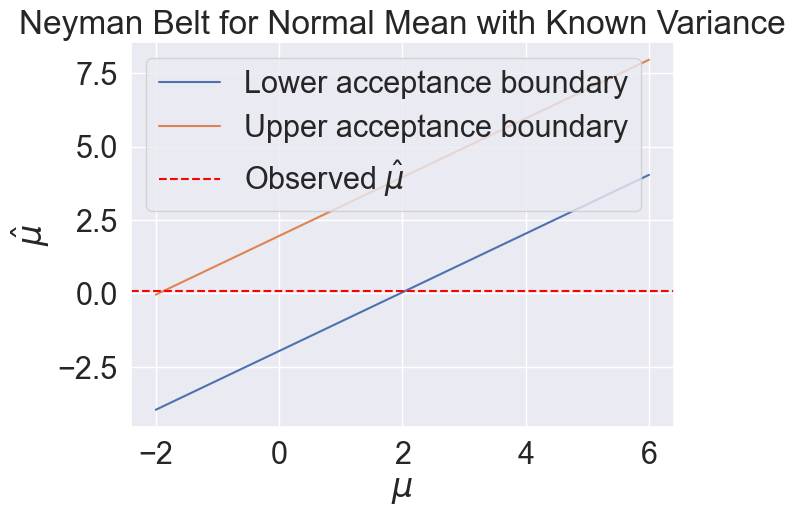

In [49]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

sigma = 1
n = 1
alpha = 0.05
z = norm.ppf(1 - alpha/2)

mu_grid = np.linspace(-2, 6, 400)

mu_low_curve  = mu_grid - z * sigma/np.sqrt(n)
mu_high_curve = mu_grid + z * sigma/np.sqrt(n)

plt.figure(figsize=(7,5))
plt.plot(mu_grid, mu_low_curve,  label="Lower acceptance boundary")
plt.plot(mu_grid, mu_high_curve, label="Upper acceptance boundary")

hat_mu_obs = 0.1
plt.axhline(hat_mu_obs, color='red', linestyle='--', label="Observed $\hat{\mu}$")

plt.xlabel(r"$\mu$")
plt.ylabel(r"$\hat{\mu}$")
plt.legend()
plt.title("Neyman Belt for Normal Mean with Known Variance")
plt.grid(True)
plt.show()

## 1.2 For the Poisson distribution

For mathematical simplicity, we will consider the case where our sample consists of a single observation, i.e.   $X = [x_1]$.   Then $\hat{\lambda} = x_1$.

**Q3: To construct the lower confidence interval, which expression should we minimize?**

1) $ \big( 1 - \mathrm{poisson.cdf}(k=\hat{\lambda},\, \mu=\lambda) - \alpha \big)^2 $

2) $ \big( 1 - \mathrm{poisson.cdf}(k=\hat{\lambda}+1,\, \mu=\lambda) - \alpha \big)^2 $

3) $ \big( 1 - \mathrm{poisson.cdf}(k=\hat{\lambda}-1,\, \mu=\lambda) - \alpha \big)^2  \checkmark$

4) $ \big( 1 - \mathrm{poisson.cdf}(k=\lambda - \mathrm{int}(\hat{\lambda}),\, \mu=\lambda) - \alpha \big)^2 $

In [50]:
from scipy.stats import poisson
def poisson_cdf_opt_problem(lam, hat_lam=1., upper=True, alpha=0.05):
    if upper:
        return (poisson.cdf(k=hat_lam, mu=lam) - alpha)**2
    else:
        return (
            (1 - poisson.cdf(k=hat_lam - 1, mu=lam)) - alpha
        )**2

In [51]:
upper_bounds = []
upper_bounds_one_sided = []
lower_bounds = []

hat_lams = np.arange(200) 
for hat_lam in hat_lams:
    res = minimize(partial(poisson_cdf_opt_problem, alpha=first_type_error_rate / 2, upper=True, hat_lam=hat_lam), [hat_lam], method='Nelder-Mead', tol=1e-6)
    upper_bounds.append(res.x[0])
    res = minimize(partial(poisson_cdf_opt_problem, alpha=first_type_error_rate / 2, upper=False, hat_lam=hat_lam), [hat_lam / 2], method='Nelder-Mead', tol=1e-6)
    lower_bounds.append(res.x[0])
    
    res = minimize(partial(poisson_cdf_opt_problem, alpha=first_type_error_rate, upper=True, hat_lam=hat_lam), [hat_lam], method='Nelder-Mead', tol=1e-6)
    upper_bounds_one_sided.append(res.x[0])

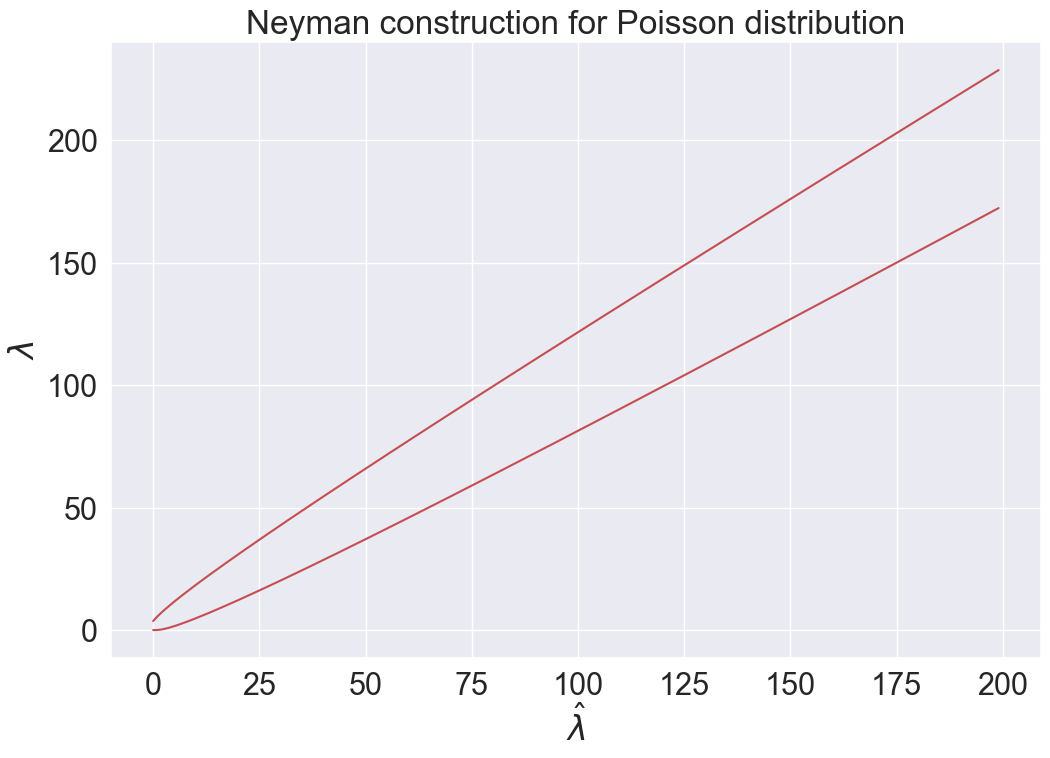

In [52]:
plt.figure(figsize=(12, 8))
# plt.plot(hat_lams, upper_bounds_one_sided, c="b")
plt.plot(hat_lams, upper_bounds, c="r")
plt.plot(hat_lams, lower_bounds, c="r")
plt.xlabel(r"$\hat\lambda$")
plt.ylabel(r"$\lambda$")
plt.title("Neyman construction for Poisson distribution")
plt.show()

In [53]:
def calculate_coverage_for_poisson(lam, lower_bounds, upper_bounds):
    coverage = 0
    for i in range(len(lower_bounds)):
        if lower_bounds[i] <= lam <= upper_bounds[i]:
            coverage += poisson.pmf(k=i, mu=lam)
    return coverage

In [54]:
coverage = []
for lam in np.linspace(1, 100, 100):    
    coverage.append(
        calculate_coverage_for_poisson(lam=lam, lower_bounds=lower_bounds, upper_bounds=upper_bounds)
    )

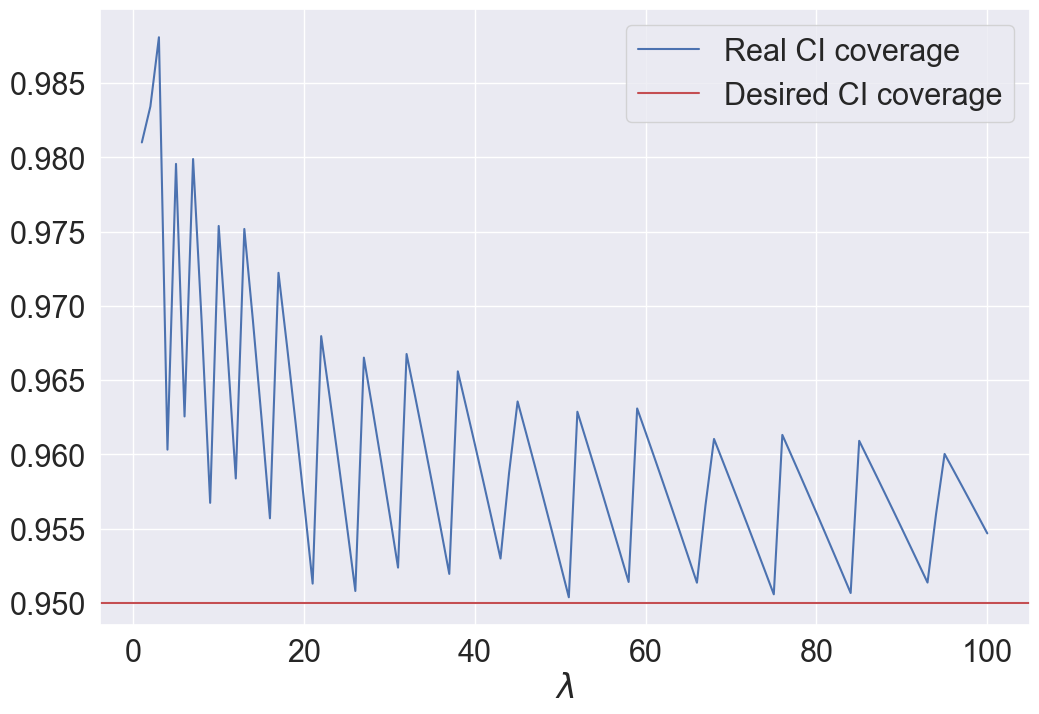

In [55]:
plt.figure(figsize=(12, 8))
plt.plot(np.linspace(1, 100, 100), coverage, label="Real CI coverage")
plt.axhline(1 - first_type_error_rate, c='r', label="Desired CI coverage")
plt.xlabel(r"$\lambda$")
plt.legend()
plt.show()

Q4: Is it accidental that the test gives overcoverage?

1) Yes, we just got lucky with the Poisson distribution.

2) No, it is not accidental.


Q5: What is a p-value?

1) The probability that our hypothesis about the data is true.

2) The probability of observing a more extreme value than the one we measured.

3) The probability of observing the measured data assuming that our hypothesis is true.

4) The probability that our hypothesis about the data is not true.

5) There is no correct answer.

### Confidence Density

1. Fix the observed value $\hat{\lambda}$.

2. Compute the derivative of the p-value $(\hat{\lambda})$ with respect to the parameter $\lambda$:

   $$
   c(\lambda) = \frac{d}{d\lambda} P(T \ge \hat{\lambda} \mid \lambda)
   $$

3. This quantity is called the *confidence density* in statistics. It represents our subjective degree of confidence about where the true value of $\lambda$ lies.

#### In practice, there is some arbitrariness in how to compute the p-value (depending on whether we want a one-sided or two-sided interval):

For constructing the Neyman interval, we solved the following two equations:

$$p(T \ge \hat{\lambda} \mid \lambda) = \alpha / 2$$

$$p(T > \hat{\lambda} \mid \lambda) = 1 - \alpha / 2$$

Because of this, the definition of the p-value becomes highly non‑obvious. Possible variants include:

$$\mathrm{p\text{-}value}(\hat{\theta}) = P(T \ge \hat{\theta} \mid \lambda)$$

$$\mathrm{p\text{-}value}(\hat{\theta}) = P(T > \hat{\theta} \mid \lambda)$$

$$\mathrm{p\text{-}value}(\hat{\theta}) = P(T > \hat{\theta} \mid \lambda) + \frac{1}{2} P(T = \hat{\theta} \mid \lambda)$$

Additional references: Lancaster (1961), Agresti (1996).

In [56]:
def derivative(f, x0, dx=1e-6):
    return (f(x0 + dx) - f(x0 - dx)) / (2 * dx)

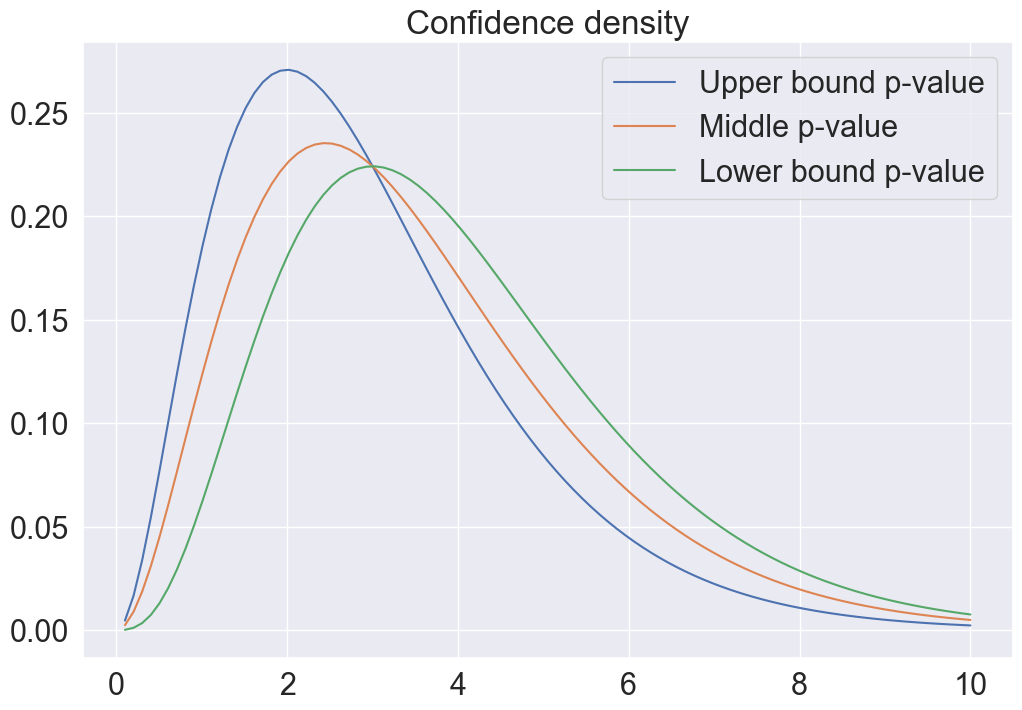

In [57]:
lam = np.linspace(0, 10, 100)
hat_lam = 3

plt.figure(figsize=(12, 8))

# Upper-tail p-value (>=)
poisson_p_value = lambda lam, hat_lam: 1 - poisson.cdf(k=hat_lam, mu=lam) + poisson.pmf(k=hat_lam, mu=lam)
plt.plot(
    lam,
    derivative(lambda l: poisson_p_value(l, hat_lam), x0=lam, dx=0.001),
    label="Upper bound p-value"
)

# Mid-p-value
poisson_p_value = lambda lam, hat_lam: 1 - poisson.cdf(k=hat_lam, mu=lam) + 0.5 * poisson.pmf(k=hat_lam, mu=lam)
plt.plot(
    lam,
    derivative(lambda l: poisson_p_value(l, hat_lam), x0=lam, dx=0.001),
    label="Middle p-value"
)

# Lower-tail p-value (>)
poisson_p_value = lambda lam, hat_lam: 1 - poisson.cdf(k=hat_lam, mu=lam)
plt.plot(
    lam,
    derivative(lambda l: poisson_p_value(l, hat_lam), x0=lam, dx=0.001),
    label="Lower bound p-value"
)

plt.title("Confidence density")
plt.legend()
plt.show()

## 1.3 For the Bernoulli case

In [58]:
from scipy.stats import binom
from scipy.optimize import brute

def bernoulli_cdf_opt_problem(p, x, n, upper=True, alpha=0.05):
    if upper:
        return (
            binom.cdf(x, n=n, p=p) - alpha
        )**2
    else:
        return (
            (1 - binom.cdf(x - 1, n=n, p=p)) - alpha
        )**2

In [59]:
EPS = 1e-3

In [60]:
n = 100
upper_bounds = []
lower_bounds = []
seeds = np.linspace(EPS, 1 - EPS, 10000)
for x in np.arange(0, n + 1):
    x_init = np.argmin((binom.cdf(x - 1, n=n, p=seeds) - first_type_error_rate / 2)**2)
    x_init = seeds[x_init]
    res = minimize(
        partial(bernoulli_cdf_opt_problem, alpha=first_type_error_rate / 2, upper=True, n=n, x=x), 
        [x_init], 
        method='Nelder-Mead', tol=1e-6, options={"maxiter": 1e5})
    upper_bounds.append(res.x[0])
    
    x_init = np.argmin((1 - binom.cdf(x - 1, n=n, p=seeds) - first_type_error_rate / 2)**2)
    x_init = seeds[x_init]
    res = minimize(
        partial(bernoulli_cdf_opt_problem, alpha=first_type_error_rate / 2, upper=False, n=n, x=x), 
        [x_init], 
        method='Nelder-Mead', tol=1e-6, options={"maxiter": 1e5})
    lower_bounds.append(res.x[0])

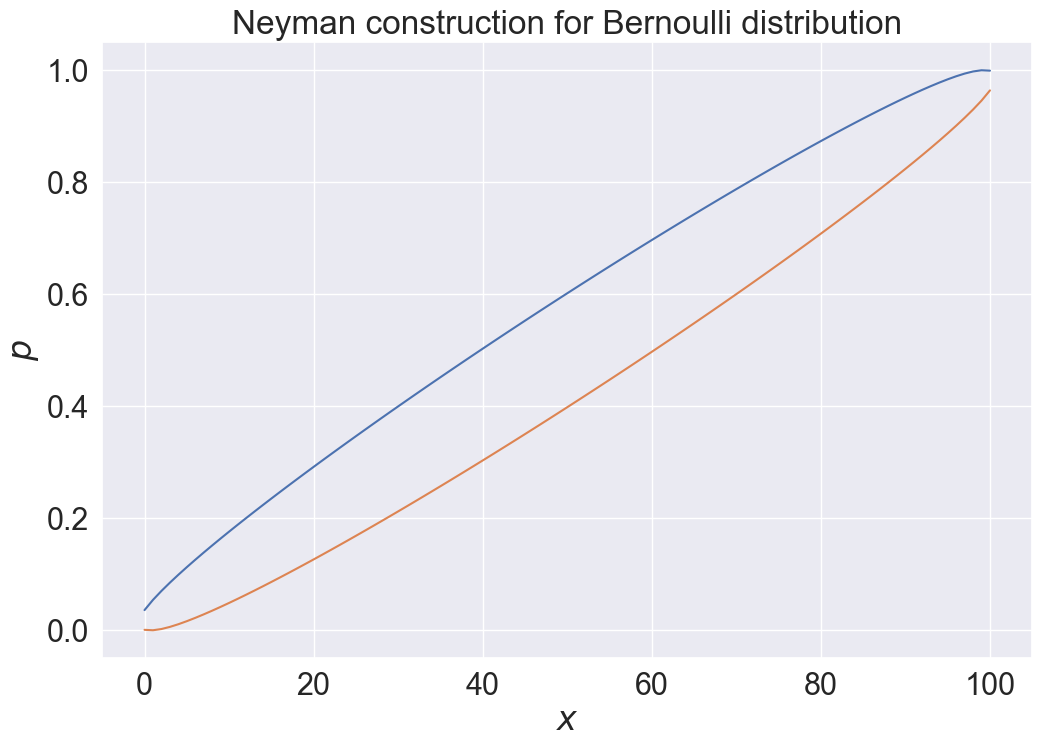

In [61]:
plt.figure(figsize=(12, 8))

plt.plot(np.arange(0, n + 1), upper_bounds)
plt.plot(np.arange(0, n + 1), lower_bounds)
plt.xlabel(r"$x$")
plt.ylabel(r"$p$")
plt.title("Neyman construction for Bernoulli distribution")
plt.show()

In [62]:
def calculate_coverage_for_bernoulli(p, n, lower_bounds, upper_bounds):
    coverage = 0
    for i in range(len(lower_bounds)):
        if lower_bounds[i] <= p <= upper_bounds[i]:
            coverage += binom.pmf(i, p=p, n=n)
    return coverage

In [63]:
coverage = []
EPS = 1e-2
for p in np.linspace(EPS, 1 - EPS, 100):    
    coverage.append(
        calculate_coverage_for_bernoulli(p=p, n=n, lower_bounds=lower_bounds, upper_bounds=upper_bounds)
    )

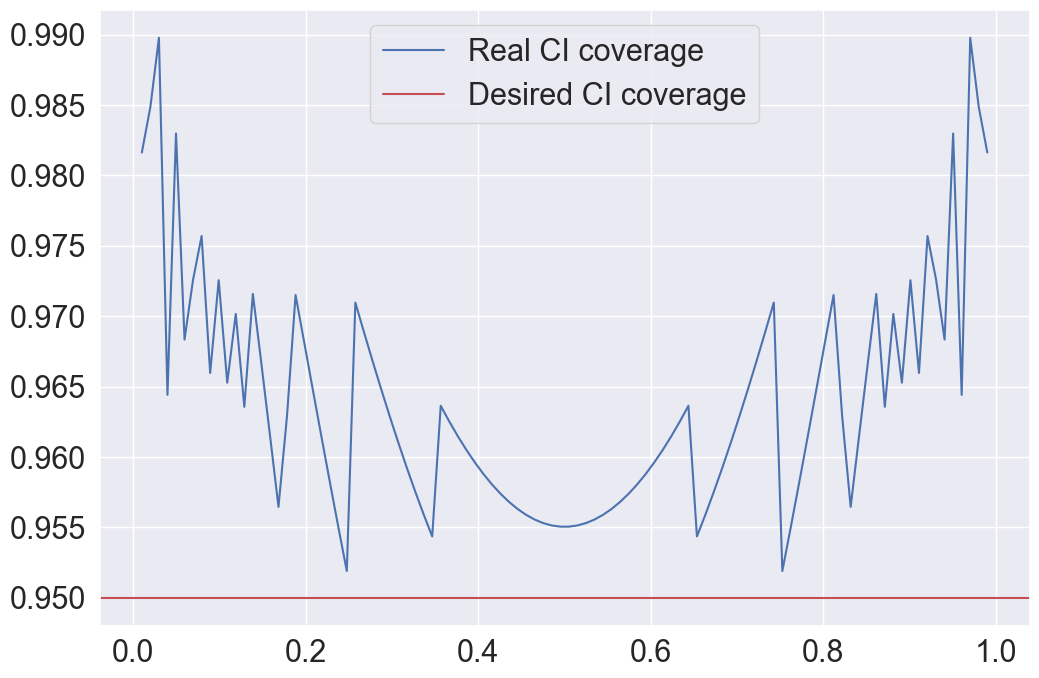

In [64]:
plt.figure(figsize=(12, 8))
plt.plot(np.linspace(EPS, 1 - EPS, 100), coverage, label="Real CI coverage")
plt.axhline(1 - first_type_error_rate, c='r', label="Desired CI coverage")
plt.legend()
plt.show()

### Confidence Density

In [65]:
p = 0.5
n = 100

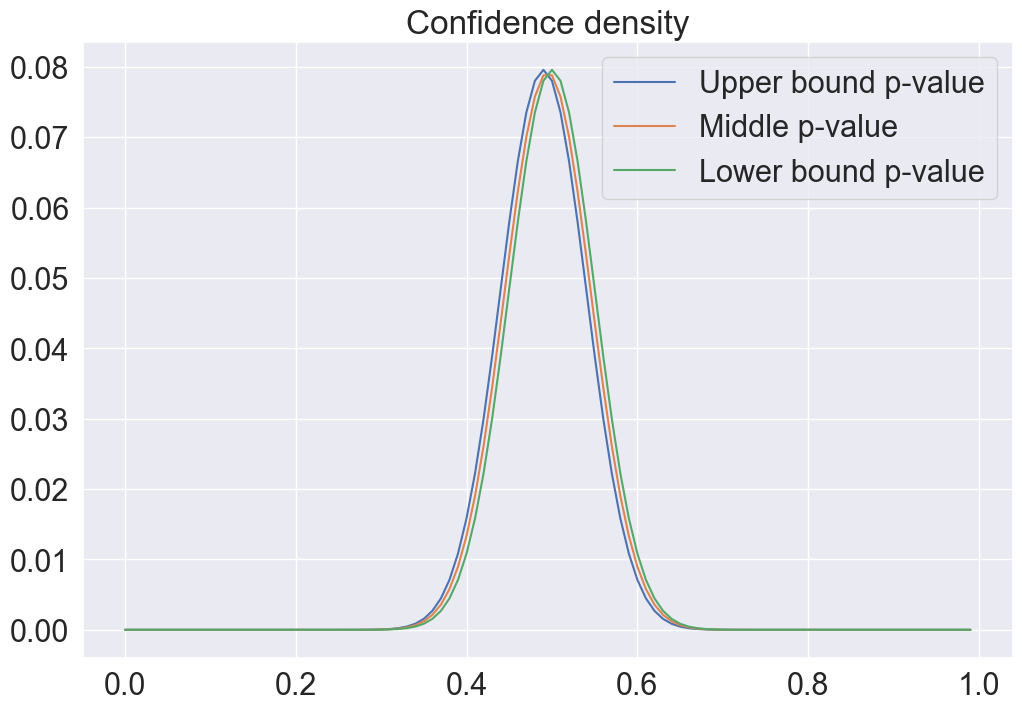

In [66]:
x = np.arange(0, n + 1)

plt.figure(figsize=(12, 8))

bernoulli_p_value = lambda p, x, n: -(1 - binom.cdf(x, n=n, p=p))
plt.plot(
    x[:-1] / n,
    np.diff(bernoulli_p_value(p=p, x=x, n=n)),
    label="Upper bound p-value"
)

bernoulli_p_value = lambda p, x, n: -((1 - binom.cdf(x, n=n, p=p)) + binom.pmf(x, n=n, p=p) / 2)
plt.plot(
    x[:-1] / n,
    np.diff(bernoulli_p_value(p=p, x=x, n=n)),
    label="Middle p-value"
)

bernoulli_p_value = lambda p, x, n: -((1 - binom.cdf(x, n=n, p=p)) + binom.pmf(x, n=n, p=p))
plt.plot(
    x[:-1] / n,
    np.diff(bernoulli_p_value(p=p, x=x, n=n)),
    label="Lower bound p-value"
)

plt.title("Confidence density")
plt.legend()
plt.show()

## For the gamma distribution

In [67]:
from collections import defaultdict
from scipy.stats import gamma

In [68]:
# true parameters of the distribution
alpha = 0.23
beta = 5.35

In [69]:
# simulations fo the dataset
boot_size = 1000
betas = np.linspace(3, 8, 50)
distributions_of_beta_hat = defaultdict(list)
for beta in betas:
    for _ in range(boot_size):
        X = gamma.rvs(scale=1 / beta, a=alpha, size=1000)
        _, _, fit_beta = gamma.fit(X, floc=0, fa=alpha)
        distributions_of_beta_hat[beta].append(1 / fit_beta)

In [70]:
# test statistic estimated from data
first_type_error_rate = 0.1
beta_hat_from_data = 6.0

upper_bound = None
for beta in betas:
    if np.mean(np.array(distributions_of_beta_hat[beta]) < beta_hat_from_data) < first_type_error_rate / 2:
        upper_bound = beta
        break
        
lower_bound = None
for beta in betas[::-1]:
    if np.mean(np.array(distributions_of_beta_hat[beta]) > beta_hat_from_data) < first_type_error_rate / 2:
        lower_bound = beta
        break

In [71]:
lower_bound, upper_bound

(np.float64(5.346938775510204), np.float64(6.775510204081632))

### Constructing the confidence belt

In [72]:
upper_bounds = []
lower_bounds = []
beta_hats = np.linspace(4.5, 6, 20)
for beta_hat in beta_hats:
    upper_bound = None
    for beta in betas:
        if np.mean(np.array(distributions_of_beta_hat[beta]) < beta_hat) < first_type_error_rate / 2:
            upper_bound = beta
            break

    lower_bound = None
    for beta in betas[::-1]:
        if np.mean(np.array(distributions_of_beta_hat[beta]) > beta_hat) < first_type_error_rate / 2:
            lower_bound = beta
            break
    upper_bounds.append(upper_bound)
    lower_bounds.append(lower_bound)

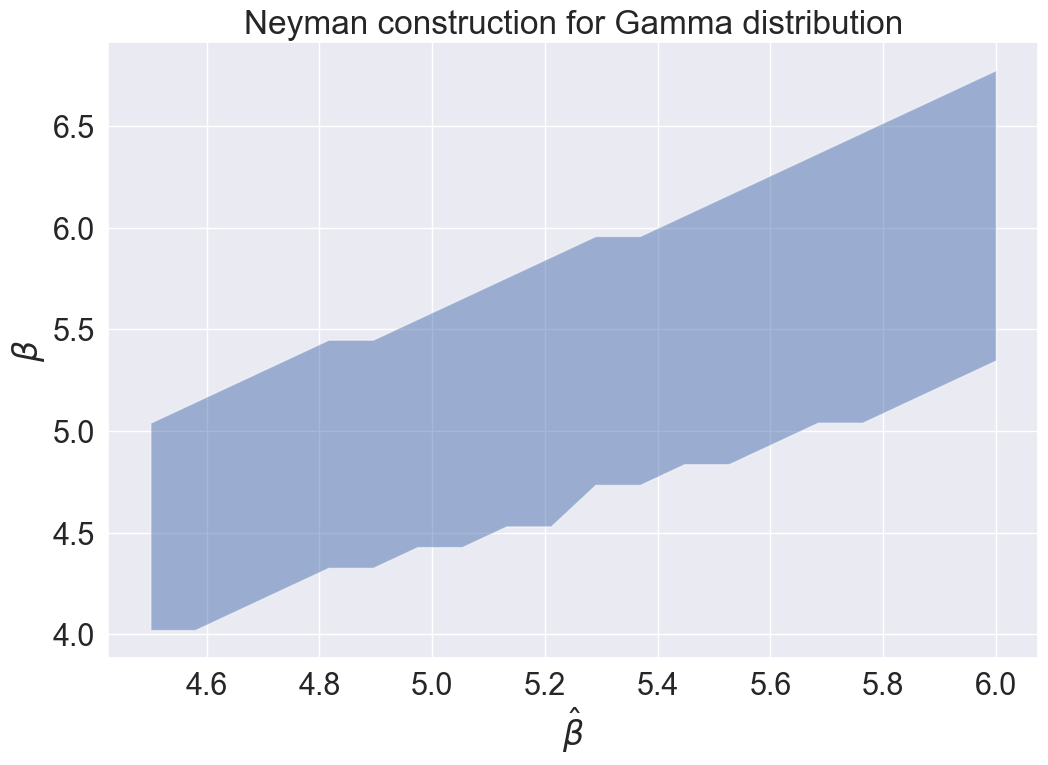

In [73]:
plt.figure(figsize=(12, 8))
plt.title("Neyman construction for Gamma distribution")
plt.fill_between(beta_hats, lower_bounds, upper_bounds, alpha=0.5)
plt.xlabel(r"$\hat\beta$")
plt.ylabel(r"$\beta$")
plt.show()

# Feldman-Cousine intervals

## Flip-flop problem

Q6: What is the task in the flip-flop problem?

1) The problem of constructing confidence intervals for discrete distributions (called flip-flop because of the association with coin flips).

2) We want to give a one-sided confidence interval if the probability of the hypothesis being true is high ($\mu > 3\sigma$), and a two-sided interval if the probability is low.

3) We want to give a two-sided confidence interval if the probability of the hypothesis being true is high ($\mu > 3\sigma$), and a one-sided interval if the probability is low. $\checkmark$

In [74]:
sigma = 1.
upper_bounds = []
lower_bounds = []
alpha = 0.1
hat_mus = np.linspace(-1, 8, 1000)
for hat_mu in hat_mus:
    if hat_mu < sigma * 3:
        lower_bounds.append(0)
        upper_bounds.append(norm.ppf(1 - alpha, loc=hat_mu, scale=sigma))
    else:
        lower_bounds.append(norm.ppf(alpha / 2, loc=hat_mu, scale=sigma))
        upper_bounds.append(norm.ppf(1 - alpha / 2, loc=hat_mu, scale=sigma))

C:\Users\Khaled\AppData\Local\Temp\ipykernel_10140\2014155432.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


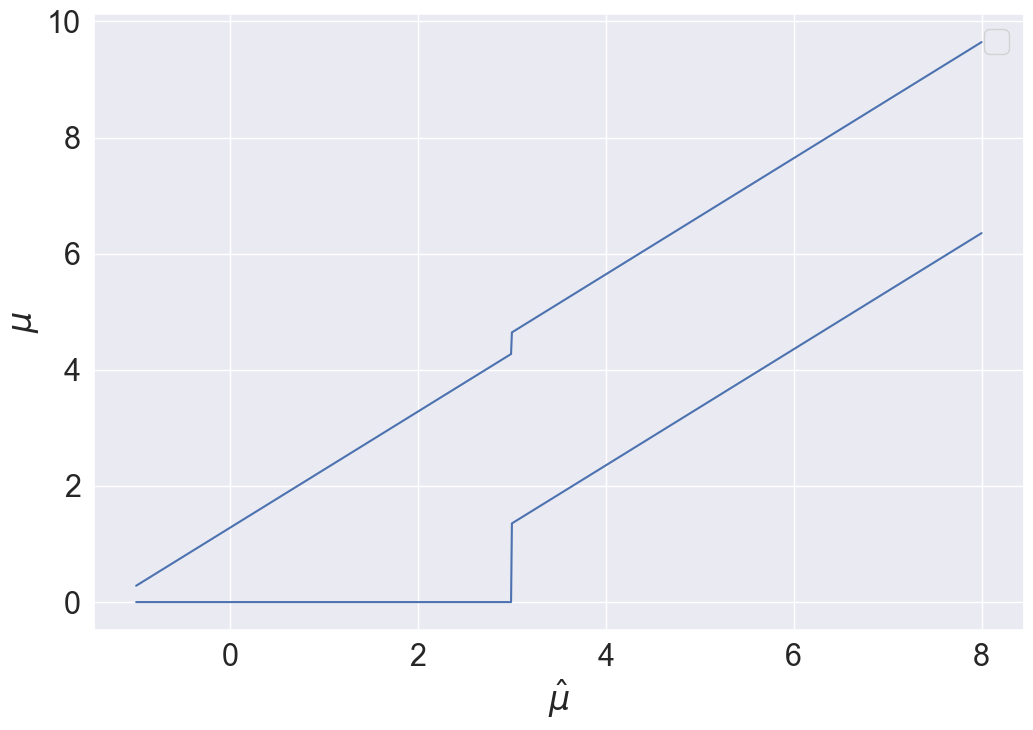

In [75]:
plt.figure(figsize=(12, 8))

plt.plot(hat_mus, upper_bounds, c="b")
plt.plot(hat_mus, lower_bounds, c="b")

plt.xlabel(r"$\hat\mu$")
plt.ylabel(r"$\mu$")
plt.legend()
plt.show()

Q7: Why is this interval bad?

1) It gives undercoverage in the left part of the plot. $\checkmark$

2) It gives overcoverage in the left part of the plot.

3) It gives undercoverage in the right part of the plot.

4) It gives overcoverage in the right part of the plot.

5) It gives undercoverage in the middle part of the plot.

6) It gives overcoverage in the middle part of the plot.

C:\Users\Khaled\AppData\Local\Temp\ipykernel_10140\729298761.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


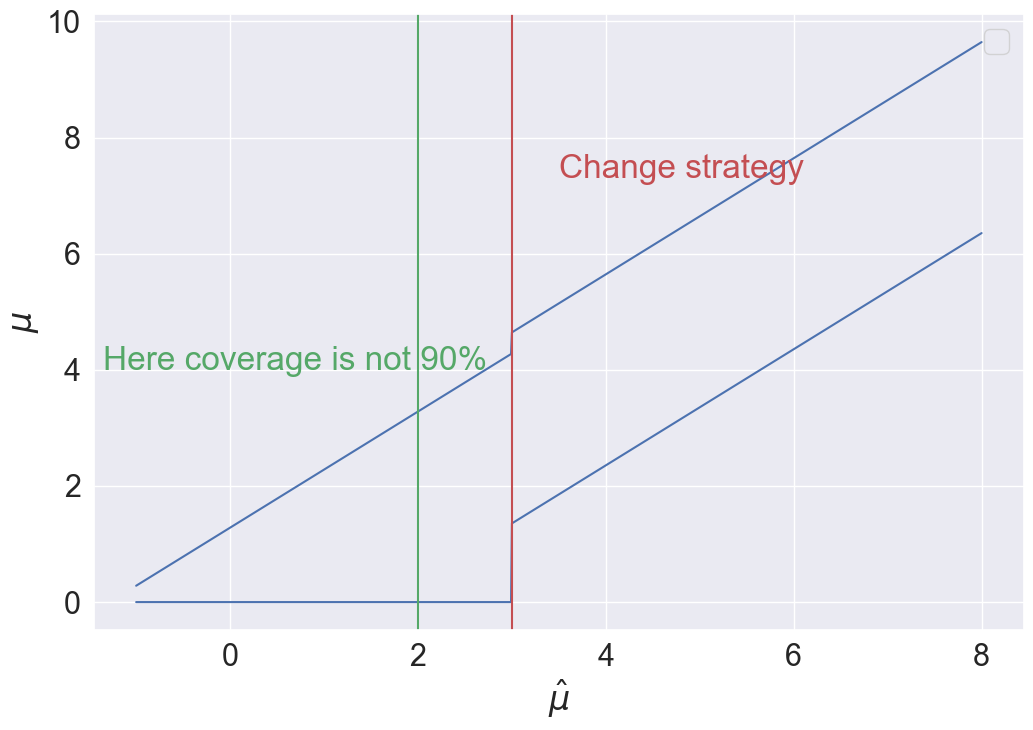

In [76]:
plt.figure(figsize=(12, 8))

plt.plot(hat_mus, upper_bounds, c="b")
plt.plot(hat_mus, lower_bounds, c="b")

plt.axvline(3, c="r")
plt.axvline(2, c="g")
plt.text(-1.35, 4, "Here coverage is not 90%", c='g')
plt.text(3.5, 7.3, "Change strategy", c="r")
plt.xlabel(r"$\hat\mu$")
plt.ylabel(r"$\mu$")
plt.legend()
plt.show()

### What should we do?

## Feldman–Cousins technique

Construct the Neyman belt in the following way:

$$
\hat{\Theta}:
\begin{cases}
\dfrac{p(\hat{\theta} \mid \theta)}{p(\hat{\theta} \mid \theta_{\max})} \ge \kappa \\
\kappa: \; P(\hat{\Theta}) = 1 - \alpha
\end{cases},
$$

where $\theta_{\max}$ is chosen via the MLE **within the allowed parameter space**.

### Proposed algorithm

In [83]:
mu = 0.1
sigma = 1.

In [84]:
def simulate_likelihood_ratios(mu, sigma, boot=20000):
    likelihood_ratios = []
    hat_mus = []
    hat_mus = norm.rvs(size=boot, loc=mu, scale=sigma)
    likelihood_ratios = (
        norm.logpdf(hat_mus, loc=np.clip(hat_mus, 0, np.inf), scale=sigma) - 
        norm.logpdf(hat_mus, loc=mu, scale=sigma)
    )
    idx_sorted = np.argsort(hat_mus)
    hat_mus = np.array(hat_mus)[idx_sorted]
    likelihood_ratios = np.array(likelihood_ratios)[idx_sorted]
    return hat_mus, likelihood_ratios

In [85]:
first_type_error_rate = 0.1

In [86]:
hat_mus, likelihood_ratios = simulate_likelihood_ratios(mu, sigma)
cut_value = np.percentile(likelihood_ratios, q=100 * (1 - first_type_error_rate))

In [87]:
hat_mus[likelihood_ratios < cut_value].min(), hat_mus[likelihood_ratios < cut_value].max()

(np.float64(-3.7207725601429726), np.float64(1.39041130756609))

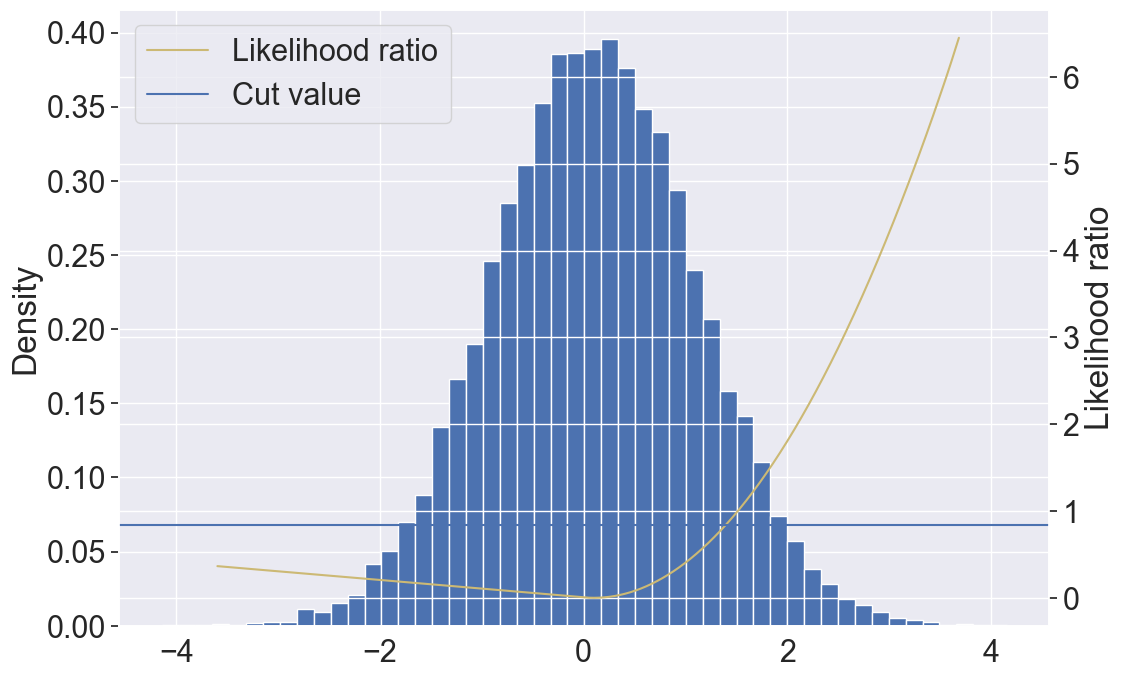

In [82]:
plt.figure(figsize=(12, 8))

plt.hist(hat_mus, bins=50, density=True);
plt.ylabel("Density")

plt.twinx()
window = 10
plt.plot(
    pd.Series(hat_mus).rolling(window=window).mean(),
    pd.Series(likelihood_ratios).rolling(window=window).mean(),
    c='y',
    label="Likelihood ratio"
)
plt.axhline(cut_value, label="Cut value")
plt.xlabel(r"$\hat\mu$")
plt.ylabel("Likelihood ratio")
plt.legend()

plt.show()

In [88]:
mus = np.linspace(0.1, 5, 50)
upper_bounds = []
lower_bounds = []
for mu in tqdm(mus):
    hat_mus, likelihood_ratios = simulate_likelihood_ratios(mu, sigma, boot=40000)
    cut_value = np.percentile(likelihood_ratios, q=100 * (1 - first_type_error_rate))
    lower_bounds.append(hat_mus[likelihood_ratios < cut_value].min())
    upper_bounds.append(hat_mus[likelihood_ratios < cut_value].max())

100%|██████████| 50/50 [00:00<00:00, 306.38it/s]


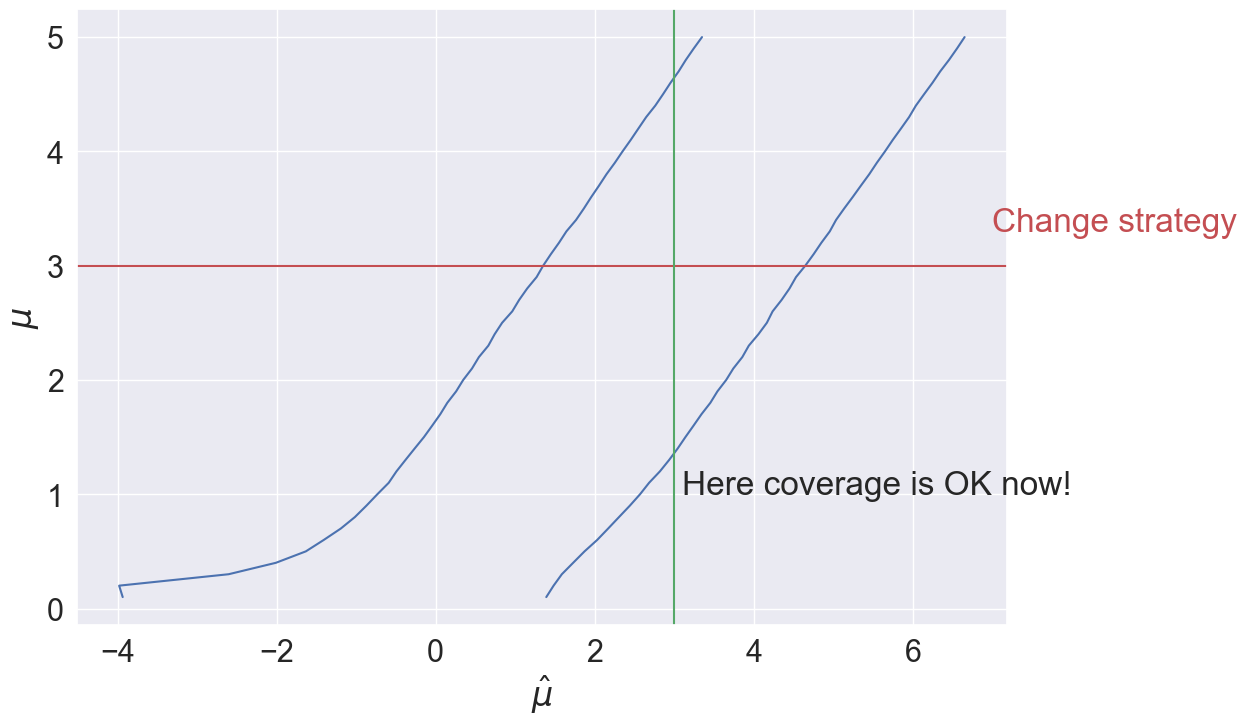

In [89]:
plt.figure(figsize=(12, 8))
plt.plot(lower_bounds, mus, c="b")
plt.plot(upper_bounds, mus, c="b")
plt.xlabel(r"$\hat\mu$")
plt.ylabel(r"$\mu$")

plt.axhline(3, c="r")
plt.axvline(3, c="g")
plt.text(3.1, 1, "Here coverage is OK now!")
plt.text(7, 3.3, "Change strategy", c="r")
plt.xlabel(r"$\hat\mu$")
plt.ylabel(r"$\mu$")

plt.show()

# 3. MAP with Jeffrey's prior

Suppose you flip a coin once and observe a head.

The distribution is Bernoulli: $p(x = 1 \mid q) = q$.

For a sample $x_1, x_2, \dots, x_N$, the likelihood is written as:

$$p(X \mid q) = \prod q^{x_i} (1 - q)^{1 - x_i}$$

$$\log p(X \mid q) = \sum \left[ x_i \log q + (1 - x_i) \log(1 - q) \right]$$

The parameter estimate is obtained as follows:

$$
\frac{\partial}{\partial q} \log p(X \mid q)
= \frac{1}{q} \sum x_i - \frac{1}{1 - q} \sum (1 - x_i) = 0
$$

Thus we get:

$$q = \frac{\sum x_i}{n}$$

According to the maximum likelihood method, this implies $q = 1$, i.e. the coin will always land heads.

Such an estimate does not agree well with reality.

### This time you don't know what distribution to expect, but you still want to slap on some prior and be a Bayesian

In this case, the best option is the non-informative Jeffreys prior:

$$p(q) \sim \sqrt{I(q)}, \qquad I(q) = \frac{1}{q(1 - q)}$$

$$p(q) \sim \frac{1}{\sqrt{q(1 - q)}}$$

Log-likelihood:

$$
\log p(X, q)\, p(q)
= -\frac{1}{2}\log q - \frac{1}{2}\log(1 - q)
+ \sum \left[ x_i \log q + (1 - x_i)\log(1 - q) \right]
$$

Derivative:

$$
\frac{\partial}{\partial q} \log p(X, q)\, p(q)
= \frac{1}{q}\sum x_i - \frac{1}{1 - q}\sum(1 - x_i)
- \frac{1}{2q} + \frac{1}{2(1 - q)} = 0
$$

Thus:

$$
q = \frac{\sum x_i + 1/2}{n + 1}
$$

In [ ]:
def bernoulli_jeffreys_prior(q):
    return 1 / np.sqrt(q * (1 - q))

In [ ]:
from scipy.stats import beta
a = b = 1.
x = np.linspace(beta.ppf(0.01, a, b),
                beta.ppf(0.99, a, b), 1000)

plt.figure(figsize=(12, 8))
plt.plot(
    x, beta.pdf(x, a, b),
    'r-', lw=5, alpha=0.6, label='Beta({}, {})'.format(a, b)
)
plt.plot(
    x, bernoulli_jeffreys_prior(x),
    'g', lw=5, alpha=0.6, label="Jeffrey's prior"
)

plt.yscale('log')
plt.legend()
plt.show()

In [ ]:
theta = 0.01
coin_flips = np.random.binomial(n=1, p=theta, size=100)

plt.figure(figsize=(10, 8), dpi=100)

a = b = 1.
plt.plot((np.cumsum(coin_flips) + a - 1) / (np.cumsum(np.ones_like(coin_flips)) + b + a - 2), label="a={}, b={}".format(a, b))

plt.plot((np.cumsum(coin_flips) + 1 / 2) / (np.cumsum(np.ones_like(coin_flips)) + 1), label="Jeffreys prior")

plt.plot(np.cumsum(coin_flips) / np.cumsum(np.ones_like(coin_flips)), label="MLE")

plt.legend()

## Q8: What is the non-informativeness of the Jeffreys prior?

1) In the one-dimensional case, the KL distance between the prior and the posterior is maximal.

2) If some parameters change their units of measurement (kg → grams, meters → centimeters), the answer does not change.

3) It “equalizes” the importance between different scales.

4) The posterior is invariant under different parameterizations (up to a change of variables). $\checkmark$